# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** 24_25_optimizer_workflow_with_cost_and_ILP  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-02-27
### Properties script
**Goal:** to generate a cost matrix for the geometry with use of the timber datasets, then using ILP to find the best matches   
**Inputs:**
*   CSV timber dataset
*   Digital geometry

**Outputs:**
*   Best match for each element in a structure

# IMPORTING

## Dataset

In [1]:
import config
import pandas as pd

file_path = config.TIMBER_STOCK_PATH / 'complete_timber_small.csv'

# Try common combinations
read_attempts = [
    {"sep": ",", "encoding": "utf-8"},
    {"sep": ";", "encoding": "utf-8"},
    {"sep": ",", "encoding": "latin1"},
    {"sep": ";", "encoding": "latin1"},
]

df_input_stock = None
for opts in read_attempts:
    try:
        df_try = pd.read_csv(file_path, **opts)
        # Valid if we get more than 1 column
        if df_try.shape[1] > 1:
            df_input_stock = df_try
            print(f"✅ Loaded with sep='{opts['sep']}' and encoding='{opts['encoding']}'")
            break
    except Exception:
        pass

if df_input_stock is None:
    raise ValueError("Could not parse CSV with tested delimiter/encoding combinations.")

# Clean column names
df_input_stock.columns = df_input_stock.columns.str.strip()

print("Gevonden kolommen:", df_input_stock.columns.tolist())
print(f"\nDataset bevat {df_input_stock.shape[0]} elementen\n")
display(df_input_stock.head())

✅ Systeem succesvol geladen.
📂 Code draait lokaal vanuit: thesis_generative_timber
☁️ Data gekoppeld aan OneDrive: 2.2 - 2.4
✅ Loaded with sep=',' and encoding='utf-8'
Gevonden kolommen: ['Member_ID', 'State', 'Length', 'Depth', 'Width', 'f_mk', 'E_modulus_eff', 'E_modulus_005', 'f_vk', 'f_c0k', 'k_density', 'mean_density', 'ECC', 'Origin_Country', 'Transport_Dist', 'Emmisiefactor', 'Bewerkingsfactor']

Dataset bevat 20 elementen



,Member_ID,State,Length,Depth,Width,f_mk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,k_density,mean_density,ECC,Origin_Country,Transport_Dist,Emmisiefactor,Bewerkingsfactor
0,NS_00069,0,2100.0,100.0,50.0,24.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Polen,828.01,0.1786,0
1,NS_00203,0,3000.0,300.0,300.0,24.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Zweden,1011.25,0.1723,0
2,NS_00009,0,1500.0,150.0,100.0,24.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Duitsland,343.26,0.1758,0
3,NS_00027,0,1500.0,250.0,100.0,24.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,België,158.07,0.1769,0
4,NS_00164,0,2700.0,250.0,250.0,24.0,11000.0,7400.0,2.5,21.0,350.0,420.0,150.0,Duitsland,316.34,0.1745,0


## Search space

De search space wordt vanuit het geometrie script geimporteerd, dan wordt een willekeurige samenstelling gekozen als beginpunt van de optimalisatie.


In [2]:
import json

json_path = 'search_space.json'
# Lees het "contract" in voor je optimizer
with open(json_path, 'r') as f:
    optimizer_search_space = json.load(f)

print(f"✅ Search Space ingeladen! De optimizer heeft {len(optimizer_search_space)} parameters om aan te draaien.")
# Nu kun je deze variabele direct aan je Optuna, PyTorch of Genetisch Algoritme voeren!

✅ Search Space ingeladen! De optimizer heeft 3 parameters om aan te draaien.


Dit script is bedoeld voor je Colab-omgeving. Het leest de search_space.json in, stelt de parameters dynamisch in op basis van jouw regels, en gebruikt een "dummy" voorspelling (waar later je echte Neurale Netwerk komt) om het beste ontwerp te vinden.

# GEOMETRY

## Random geometry

In [3]:
import json
import random
import c11_params

# ==========================================
# 1. RANDOM PARAMETERS GENEREREN (De "DNA" string)
# ==========================================
def get_random_design(json_path):
    """Leest de search space en trekt voor elke knop een willekeurige waarde."""
    with open(json_path, 'r') as f:
        search_space = json.load(f)

    random_params = {}

    for var_name, rules in search_space.items():
        if rules['type'] == 'continuous':
            # Kies een willekeurig kommagetal (bijv. voor u en v)
            random_params[var_name] = random.uniform(rules['min'], rules['max'])

        elif rules['type'] == 'discrete':
            # Kies exact één van de toegestane stapjes (bijv. voor shift_x)
            random_params[var_name] = random.choice(rules['options'])

    return random_params

# --- TEST DE FUNCTIE ---
print("Stap 1: Willekeurig DNA genereren...")
mijn_random_ontwerp = get_random_design(json_path)

print("\nSucces! Dit is het DNA van ons proef-ontwerp:")
for sleutel, waarde in mijn_random_ontwerp.items():
    print(f" - {sleutel}: \t{waarde:.3f}")

Stap 1: Willekeurig DNA genereren...

Succes! Dit is het DNA van ons proef-ontwerp:
 - v4_u: 	0.638
 - v4_v: 	0.430
 - v4_shift_z: 	-1.125


# Opzet

In [4]:
import pandas as pd
from geometry import generate_sample_vertices
from reconstruction import reconstruct_edges

# --- UITVOEREN VAN STAP 2 ---
print("Stap 2: DNA vertalen naar 3D Geometrie...")

# We gebruiken 'mijn_random_ontwerp' uit de VORIGE cel!
vertices_list = generate_sample_vertices(sample_id=0, params=mijn_random_ontwerp)
df_vertices = pd.DataFrame(vertices_list)
df_edges = reconstruct_edges(c11_params.GRID_CELLS_X, c11_params.GRID_CELLS_Y)

print(f"✅ Succes! Geometrie opgebouwd met {len(df_vertices)} knooppunten en {len(df_edges)} staven.")
print("\nVoorbeeld van de gegenereerde Vertices (eerste 5):")
print(df_vertices.head())

Stap 2: DNA vertalen naar 3D Geometrie...
✅ Succes! Geometrie opgebouwd met 5 knooppunten en 8 staven.

Voorbeeld van de gegenereerde Vertices (eerste 5):
   sample_id vertex_index   layer attribute      x      y      z
0          0           v0     top   support  0.000  0.000  0.000
1          0           v1     top   support  3.000  0.000  0.000
2          0           v2     top   support  0.000  3.000  0.000
3          0           v3     top   support  3.000  3.000  0.000
4          0           v4  bottom    hinges  1.914  1.289 -2.625


## Quick 3D visual check

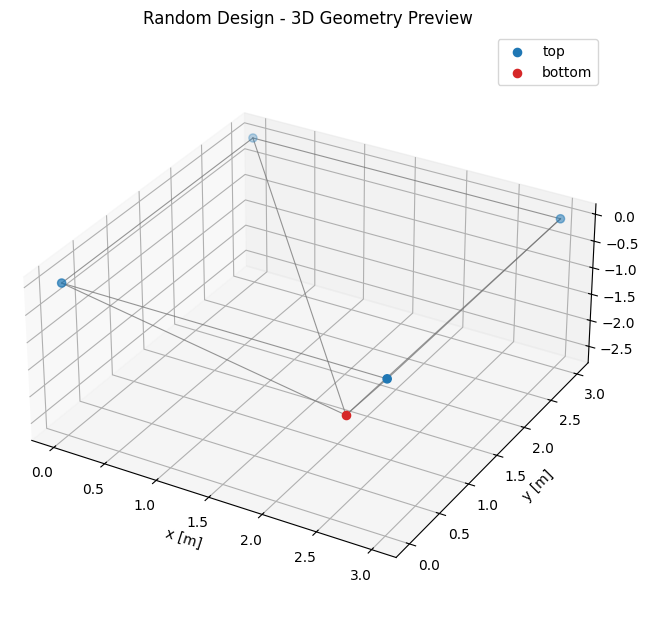

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Build a lookup so we can quickly fetch coordinates for each vertex id.
vertex_lookup = df_vertices.set_index("vertex_index")[["x", "y", "z", "layer"]].to_dict("index")

def _to_vertex_key(v):
    v_str = str(v)
    return v_str if v_str.startswith("v") else f"v{v_str}"

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Draw all members (edges)
for _, edge in df_edges.iterrows():
    v1 = _to_vertex_key(edge["V1"])
    v2 = _to_vertex_key(edge["V2"])

    if v1 not in vertex_lookup or v2 not in vertex_lookup:
        continue

    p1 = vertex_lookup[v1]
    p2 = vertex_lookup[v2]
    ax.plot3D(
        [p1["x"], p2["x"]],
        [p1["y"], p2["y"]],
        [p1["z"], p2["z"]],
        color="0.45",
        linewidth=0.8,
        alpha=0.75,
    )

# Draw nodes per layer for readability
df_top = df_vertices[df_vertices["layer"] == "top"]
df_bottom = df_vertices[df_vertices["layer"] == "bottom"]

ax.scatter3D(
    np.asarray(df_top["x"]),
    np.asarray(df_top["y"]),
    np.asarray(df_top["z"]),
    s=35,
    c="#1f77b4",
    label="top",
)
ax.scatter3D(
    np.asarray(df_bottom["x"]),
    np.asarray(df_bottom["y"]),
    np.asarray(df_bottom["z"]),
    s=35,
    c="#d62728",
    label="bottom",
)

ax.set_title("Random Design - 3D Geometry Preview")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]", labelpad=14)
ax.legend(loc="upper right")
ax.set_box_aspect((1, 1, 0.45))

# Keep extra space on the right so the z label is fully visible.
fig.subplots_adjust(left=0.06, right=0.90, bottom=0.08, top=0.93)
plt.show()

## Feature extraction

In [6]:
import pandas as pd
from reconstruction import extract_beam_properties

# --- UITVOEREN VAN STAP 3 ---
print("Stap 3: Staaflengtes en profielen berekenen...")

# We gebruiken de tabellen uit de VORIGE cel!
df_slots = extract_beam_properties(df_vertices, df_edges)

print(f"✅ Succes! We hebben de eigenschappen van {len(df_slots)} balken berekend.")
print("\nDit is de input (Slots) voor je Cost Matrix (eerste 10 balken):")
print(df_slots.head(10))

Stap 3: Staaflengtes en profielen berekenen...
✅ Succes! We hebben de eigenschappen van 8 balken berekend.

Dit is de input (Slots) voor je Cost Matrix (eerste 10 balken):
  edge_id          type  Length_Req  Width_Req  Depth_Req
0      e0     Top Chord     3000.00       75.0      150.0
1      e1     Top Chord     3000.00       75.0      150.0
2      e2     Top Chord     3000.00       75.0      150.0
3      e3     Top Chord     3000.00       75.0      150.0
4      e4  Diagonal Web     3495.07       50.0      100.0
5      e5  Diagonal Web     3119.54       50.0      100.0
6      e6  Diagonal Web     3671.72       50.0      100.0
7      e7  Diagonal Web     3316.25       50.0      100.0


# COST MATRIX

Omdat de pseudo-LCA berekening (uit de vorige stap) de impact van de gehele balk al berekent, heb je nu een methodologische keuze:

Optie A (De dubbele boete): Je telt de LCA-score én de penalty's bij elkaar op. Hiermee straf je afval extra zwaar af ten opzichte van het puur inbrengen van materiaal. Dit dwingt het algoritme agressief naar optimaal materiaalgebruik.

Optie B (De uitsplitsing): Je berekent de LCA-score alleen over het nuttige deel, en gebruikt je nieuwe formules om het verlies in kaart te brengen.

In [7]:
# ==========================================
# CEL 1: INPUTS EN ALGEMENE PARAMETERS
# ==========================================
import pandas as pd
import numpy as np
import c11_params

print("✅ Parameters succesvol geladen.")

✅ Parameters succesvol geladen.


## Controle

In [8]:
from cost_calculation import calculate_pseudo_lca_stock

# 1. Voer de functie uit op je reeds ingeladen DataFrame
df_stock_with_lca = calculate_pseudo_lca_stock(df_input_stock)

# 2. Bekijk de resultaten van de berekening
print("\nPreview van de berekende E_cost per element:")
display(df_stock_with_lca.sample(10))

✅ Rekenmodules succesvol gedefinieerd.
Start in-memory pseudo-LCA berekeningen...

Preview van de berekende E_cost per element:


,Member_ID,State,Length,Depth,Width,f_mk,E_modulus_eff,E_modulus_005,f_vk,f_c0k,...,ECC,Origin_Country,Transport_Dist,Emmisiefactor,Bewerkingsfactor,Volume_m3,Impact_Material_kgCO2,Impact_Transport_kgCO2,Impact_Processing_kgCO2,E_cost_Total_kgCO2
19,RS_00013,1,3200.0,150.0,50.0,18.0,9000.0,6000.0,2.0,18.0,...,15.0,Netherlands,32.00,0.1739,1,0.02400,0.36000,0.050751,0.319200,0.729951
12,NS_00257,0,3600.0,200.0,150.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,Duitsland,323.02,0.1786,0,0.10800,16.20000,2.616881,0.000000,18.816881
9,NS_00245,0,3600.0,150.0,63.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,België,130.52,0.1738,0,0.03402,5.10300,0.324123,0.000000,5.427123
16,RS_00016,1,3550.0,210.0,80.0,18.0,9000.0,6000.0,2.0,18.0,...,15.0,Netherlands,143.00,0.0492,1,0.05964,0.89460,0.159449,0.793212,1.847261
3,NS_00027,0,1500.0,250.0,100.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,België,158.07,0.1769,0,0.03750,5.62500,0.440411,0.000000,6.065411
8,NS_00061,0,1800.0,250.0,100.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,Spanje & Portugal,1717.11,0.1761,0,0.04500,6.75000,5.715040,0.000000,12.465040
14,RS_00009,1,3000.0,150.0,50.0,18.0,9000.0,6000.0,2.0,18.0,...,15.0,Netherlands,133.00,0.1755,1,0.02250,0.33750,0.199570,0.299250,0.836320
13,NS_00095,0,2100.0,250.0,100.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,Duitsland,335.19,0.1738,0,0.05250,7.87500,1.284545,0.000000,9.159545
18,RS_00017,1,3100.0,150.0,50.0,18.0,9000.0,6000.0,2.0,18.0,...,15.0,Netherlands,118.00,0.1777,1,0.02325,0.34875,0.185258,0.309225,0.843233
4,NS_00164,0,2700.0,250.0,250.0,24.0,11000.0,7400.0,2.5,21.0,...,150.0,Duitsland,316.34,0.1745,0,0.16875,25.31250,3.912394,0.000000,29.224894


## Building of cost matrix

In [9]:
# Print even ter controle hoeveel balken erin zitten
print(f"Hout-inventaris succesvol ingeladen: {len(df_input_stock)} balken beschikbaar.")

Hout-inventaris succesvol ingeladen: 20 balken beschikbaar.


In [10]:
# --- Controle van de 
# Bepaal automatisch twee balken om te onderzoeken (1x RS en 1x NS)
rs_balken = df_input_stock[df_input_stock['Member_ID'].str.contains('RS')]['Member_ID'].tolist()
ns_balken = df_input_stock[df_input_stock['Member_ID'].str.contains('NS')]['Member_ID'].tolist()

balk_onderzoek = []
if rs_balken: balk_onderzoek.append(rs_balken[0]) # Pak de eerste Reclaimed balk
if ns_balken: balk_onderzoek.append(ns_balken[0]) # Pak de eerste New balk

print(f"🔍 Diepte-analyse gestart voor: {balk_onderzoek}")

🔍 Diepte-analyse gestart voor: ['RS_00009', 'NS_00069']


In [11]:
import numpy as np
import pandas as pd
import config
from cost_calculation import build_cost_matrix

# Bepaal automatisch twee balken om te onderzoeken (1x RS en 1x NS)
rs_balken = df_input_stock[df_input_stock['Member_ID'].str.contains('RS')]['Member_ID'].tolist()
ns_balken = df_input_stock[df_input_stock['Member_ID'].str.contains('NS')]['Member_ID'].tolist()

balk_onderzoek = []
if rs_balken: balk_onderzoek.append(rs_balken[0]) # Pak de eerste Reclaimed balk
if ns_balken: balk_onderzoek.append(ns_balken[0]) # Pak de eerste New balk

print(f"🔍 Diepte-analyse gestart voor: {balk_onderzoek}")

# Bouw de matrix en haal het logboek (df_logs) op
cost_matrix, verrijkte_stock, df_logs = build_cost_matrix(df_slots, df_input_stock, target_stock_ids=balk_onderzoek)

# 3. Presentatie van het resultaat
# Maak er een DataFrame van, puur om het netjes te kunnen printen.
df_cost_matrix_display = pd.DataFrame(
    cost_matrix,
    index=[f"{row['edge_id']} ({row['Length_Req']:.0f}mm)" for _, row in df_slots.iterrows()],
    columns=verrijkte_stock['Member_ID'].tolist()
)

df_cost_matrix_display.to_csv(config.EXPORT_PATH /'final_cost_matrix.csv', index=True)

# --- PRESENTEER DE DIEPTE-ANALYSE ---
print("\n" + "="*80)
print("🔬 DIEPTE-ANALYSE: ONLEDING VAN DE CO2 PENALTY")
print("="*80)

# Sorteer het logboek netjes op Stock_ID
if not df_logs.empty:
    df_logs = df_logs.sort_values(by=['Stock_ID', 'Slot_ID']).reset_index(drop=True)
    # Print als nette tabel, verwijder de NaN voor overzichtelijkheid
    print(df_logs.fillna('-').to_string(index=False))
else:
    print("Geen logboek data gevonden.")

print("="*80)

print("\nPreview Cost Matrix (eerste 8 staven, eerste 5 inventaris-balken):")
print("(Let op: 'inf' betekent dat de inventaris-balk te klein is en wordt uitgesloten)\n")
print("=" *80)
print(df_cost_matrix_display.iloc[:8, :5].round(2))

🔍 Diepte-analyse gestart voor: ['RS_00009', 'NS_00069']
Start generatie van de integrale CO2 Cost Matrix...
Start in-memory pseudo-LCA berekeningen...
✅ Matrix gegenereerd! Dimensies: 8 benodigde staven x 20 inventaris-balken.
📊 Aantal fysiek geldige combinaties gevonden: 45

🔬 DIEPTE-ANALYSE: ONLEDING VAN DE CO2 PENALTY
Slot_ID Stock_ID Status Mat_CO2 Trans_CO2 Proc_CO2 E_cost_Base Waste_CO2 Overdim_CO2  TOTAL_Score
     e0 NS_00069      ❌       -         -        -           -         -           -          inf
     e1 NS_00069      ❌       -         -        -           -         -           -          inf
     e2 NS_00069      ❌       -         -        -           -         -           -          inf
     e3 NS_00069      ❌       -         -        -           -         -           -          inf
     e4 NS_00069      ❌       -         -        -           -         -           -          inf
     e5 NS_00069      ❌       -         -        -           -         -           -     

# MATCHING ALGORITHM / ILP

## Script

In [12]:
import pulp
import numpy as np
import pandas as pd

# ==========================================
# CEL 4: TOEPASSING VAN HET OPTIMALISATIE ALGORITME (MILP)
# ==========================================
print("Start MILP Optimizer voor definitieve toewijzing...")

# 1. DATA KOPPELEN VANUIT VORIGE SCRIPTS
# Haal de namen op uit de DataFrames van de vorige cellen
stock_items = verrijkte_stock['Member_ID'].tolist()
construction_slots = df_slots['edge_id'].tolist()

# Dynamische categorisatie (kijkt naar 'NS' en 'RS' in de Member_ID)
new_items = [item for item in stock_items if 'NS' in item]
reclaimed_items = [item for item in stock_items if 'RS' in item]

print(f"📊 Inventaris: {len(reclaimed_items)} Reclaimed, {len(new_items)} New elementen.")
print(f"📐 Constructie vereist: {len(construction_slots)} staven.")

# 2. FILTEREN VAN DE COST MATRIX (Sparse Matrix Maken)
# We maken alleen combinaties aan die fysiek passen (waar de cost NIET oneindig is)
valid_matches = []
costs = {}

for i, slot_id in enumerate(construction_slots):
    for j, stock_id in enumerate(stock_items):
        cost = cost_matrix[i, j]
        # Als de cost niet 'inf' is, is het een geldige match!
        if cost != np.inf:
            valid_matches.append((stock_id, slot_id))
            costs[(stock_id, slot_id)] = cost

print(f"⚡ Aantal geldige combinaties voor de solver gereduceerd tot: {len(valid_matches)}")

# 3. HET MODEL OPZETTEN
prob = pulp.LpProblem("Reclaimed_Timber_Matching", pulp.LpMinimize)

# 4. DECISION VARIABLES
# We maken uitsluitend 'knoppen' aan voor de combinaties die kunnen passen
x = pulp.LpVariable.dicts("Match", valid_matches, 0, 1, pulp.LpBinary)

# 5. OBJECTIVE FUNCTION (Doel: Minimaliseer de totale CO2 penalty)
prob += pulp.lpSum([x[match] * costs[match] for match in valid_matches])

# 6. CONSTRAINTS (De Regels)

# Regel A: Elke staaf in de constructie MOET precies 1 balk toegewezen krijgen
for slot_id in construction_slots:
    # Zoek alle balken die überhaupt passen op dit slot
    valid_stock_for_slot = [stock_id for (stock_id, s_id) in valid_matches if s_id == slot_id]

    if not valid_stock_for_slot:
        print(f"⚠️ FATALE FOUT: Slot {slot_id} heeft GEEN ENKELE fysiek passende balk in de hele voorraad!")
    else:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for stock_id in valid_stock_for_slot]) == 1

# Regel B: Reclaimed hout is uniek (Max 1x gebruiken)
for stock_id in reclaimed_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= 1

# Regel C: Nieuw hout mag oneindig gebruikt worden (Limiet = aantal benodigde staven)
for stock_id in new_items:
    valid_slots_for_stock = [s_id for (s_id_tuple, s_id) in valid_matches if s_id_tuple == stock_id]
    if valid_slots_for_stock:
        prob += pulp.lpSum([x[(stock_id, slot_id)] for slot_id in valid_slots_for_stock]) <= len(construction_slots)

# ==========================================
# 7. OPLOSSEN EN RESULTATEN
# ==========================================
prob.solve()

print("\n" + "="*50)
print(f"STATUS OPLOSSING: {pulp.LpStatus[prob.status]}")
print("="*50)

if pulp.LpStatus[prob.status] == 'Optimal':
    total_cost = pulp.value(prob.objective)

    # Sla de winnende combinaties op in een overzichtelijke lijst
    results = []
    for j in construction_slots:
        for i in stock_items:
            match = (i, j)
            if match in x and x[match].varValue == 1:
                # Gebruik dezelfde kolomnamen als in de merge-stap
                results.append({'edge_id': j, 'assigned_timber': i, 'CO2_Penalty': round(costs[match], 2)})

    df_results = pd.DataFrame(results)

    print(f"\n✅ Het optimale ontwerp is gevonden met een totale CO2 penalty van {total_cost:.2f} kg!")

    # ==========================================
    # 8. MERGEN MET DE ORIGINELE EDGE MATRIX
    # ==========================================
    # We gebruiken pd.merge om de nieuwe 'assigned_timber' kolom naast je bestaande V1/V2 kolommen te plakken
    df_final_edges = pd.merge(df_slots, df_results[['edge_id', 'assigned_timber']], on='edge_id', how='left')

    print("\nDefinitieve Hout-Toewijzing:")
    print("-" * 50)
    print(df_results.to_string(index=False))

    # Optioneel: Exporteer dit naar CSV om in Grasshopper te kleuren
    # df_final_edges.to_csv('definitieve_toewijzing.csv', index=False)

else:
    print("❌ Het algoritme kon geen oplossing vinden. Waarschijnlijk is je voorraad niet toereikend voor de opgevraagde constructie.")

Start MILP Optimizer voor definitieve toewijzing...
📊 Inventaris: 6 Reclaimed, 14 New elementen.
📐 Constructie vereist: 8 staven.
⚡ Aantal geldige combinaties voor de solver gereduceerd tot: 45

STATUS OPLOSSING: Optimal

✅ Het optimale ontwerp is gevonden met een totale CO2 penalty van 140.38 kg!

Definitieve Hout-Toewijzing:
--------------------------------------------------
edge_id assigned_timber  CO2_Penalty
     e0        NS_00290        30.83
     e1        NS_00290        30.83
     e2        NS_00290        30.83
     e3        RS_00016         2.51
     e4        NS_00245         8.32
     e5        RS_00013         0.95
     e6        NS_00290        33.52
     e7        RS_00015         2.59


# EXPORT

This is where the best parameters of the sctructure are exported, this is done in a format that can be used by grasshopper script to translate it into geometry

In [13]:
# @title Export geometry + assigned stock
import pandas as pd
import config

# ==========================================
# 8. EXPORT VAN GEOMETRIE + MATCHING RESULTATEN
# ==========================================
# Parameters/keuzes
EXPORT_PREFIX = "optimum"              # bv. "optimum", "run01", ...
EXPORT_UNASSIGNED_AS = "UNASSIGNED"    # label voor edges zonder match
DROP_UNASSIGNED_EDGES = False           # True = alleen gematchte edges exporteren

print("\n📦 Exporteren van vertices en edges met toegewezen stock...")

# --- 1) Validatie van vereiste data uit eerdere cellen ---
required_vars = ["df_vertices", "df_edges", "df_results"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise ValueError(
        "Deze variabelen ontbreken uit eerdere cellen: " + ", ".join(missing) + 
        ". Run eerst geometry, matching en ILP-cellen."
    )

# --- 2) Maak edge export met assigned_timber ---
df_edges_export = df_edges.copy()
df_edges_export = pd.merge(
    df_edges_export,
    df_results[["edge_id", "assigned_timber", "CO2_Penalty"]],
    on="edge_id",
    how="left"
 )
df_edges_export["assigned_timber"] = df_edges_export["assigned_timber"].fillna(EXPORT_UNASSIGNED_AS)
df_edges_export["CO2_Penalty"] = df_edges_export["CO2_Penalty"].fillna(0)

if DROP_UNASSIGNED_EDGES:
    df_edges_export = df_edges_export[df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS].copy()

# --- 3) Bestandspaden opbouwen ---
pad_vertices = config.EXPORT_PATH / f"{EXPORT_PREFIX}_vertices.csv"
pad_edges = config.EXPORT_PATH / f"{EXPORT_PREFIX}_edges_with_stock.csv"

# --- 4) Exporteren ---
df_vertices.to_csv(pad_vertices, index=False)
df_edges_export.to_csv(pad_edges, index=False)

# --- 5) Samenvatting ---
n_total = len(df_edges_export)
n_matched = int((df_edges_export["assigned_timber"] != EXPORT_UNASSIGNED_AS).sum())
print(f"✅ Vertices geëxporteerd: {len(df_vertices)} -> {pad_vertices}")
print(f"✅ Edges geëxporteerd: {n_total} (matched: {n_matched}) -> {pad_edges}")

print("\nPreview edges + assigned_timber:")
display(df_edges_export.head(10))


📦 Exporteren van vertices en edges met toegewezen stock...
✅ Vertices geëxporteerd: 5 -> C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\optimum_vertices.csv
✅ Edges geëxporteerd: 8 (matched: 8) -> C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\optimum_edges_with_stock.csv

Preview edges + assigned_timber:


,edge_id,V1,V2,assigned_timber,CO2_Penalty
0,e0,0,1,NS_00290,30.83
1,e1,2,3,NS_00290,30.83
2,e2,0,2,NS_00290,30.83
3,e3,1,3,RS_00016,2.51
4,e4,4,0,NS_00245,8.32
5,e5,4,1,RS_00013,0.95
6,e6,4,2,NS_00290,33.52
7,e7,4,3,RS_00015,2.59
